# 05 - Feature Engineering

**Goal**: Extract structured features from text that ML models can use directly.

**Learning concepts**: TF-IDF (term frequency–inverse document frequency), sentiment analysis,
regex-based keyword extraction, joining structured skill data.

**Research themes addressed**:
- Theme 1 (Salary): Do description length or sentiment predict salary?
- Theme 3 (Entry-Level Paradox): Do entry-level jobs demand senior-level skills?
- Theme 4 (Engagement): Do longer/more positive descriptions get more applications?

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

from talentlens.config import (
    POSTINGS_NLP_PARQUET, POSTINGS_FEATURES_PARQUET, PROCESSED_DIR,
    JOB_SKILLS_CSV, SKILLS_MAP_CSV,
)
from talentlens.features import add_sentiment, add_senior_signals
from talentlens.plots import plot_top_categories, plot_box_by_category, save_fig

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)
%matplotlib inline

c:\Python3.13\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.3.0) or chardet (6.0.0.post1)/charset_normalizer (3.4.1) doesn't match a supported version!
  warnings.warn(


In [2]:
# Load the NLP-preprocessed dataset from notebook 04
if not POSTINGS_NLP_PARQUET.exists():
    raise FileNotFoundError(
        "postings_nlp.parquet not found! "
        "Run notebook 04-mp-nlp-text-preprocessing.ipynb first."
    )

df = pd.read_parquet(POSTINGS_NLP_PARQUET)
print(f"Loaded {len(df):,} postings with NLP preprocessing")
df.info()

Loaded 123,842 postings with NLP preprocessing
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123842 entries, 0 to 123841
Data columns (total 42 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   job_id                      123842 non-null  int64         
 1   company_name                122124 non-null  object        
 2   title                       123842 non-null  object        
 3   description                 123842 non-null  object        
 4   max_salary                  29792 non-null   float64       
 5   pay_period                  36072 non-null   object        
 6   location                    123842 non-null  object        
 7   company_id                  122126 non-null  float64       
 8   views                       122153 non-null  float64       
 9   med_salary                  6280 non-null    float64       
 10  min_salary                  29792 non-null   float64     

## 1. TF-IDF Analysis

**What is TF-IDF?** A way to measure how important a word is to a document relative to a whole collection.

- **TF** (Term Frequency): How often does this word appear in THIS document?
- **IDF** (Inverse Document Frequency): How rare is this word across ALL documents?
- **TF-IDF = TF × IDF**: Words that appear often in one document but rarely in others get high scores.

**Example**: "python" in a data science job description → high TF-IDF (specific to that job type).
"experience" in every job description → low TF-IDF (too common to be distinctive).

**Why we use the lemmatized text**: "engineer", "engineers", "engineering" would be 3 different terms.
After lemmatization, they're all "engineer" — giving a stronger, cleaner signal.

In [ ]:
# Fit TF-IDF on lemmatized descriptions
# max_features=5000: keep the top 5000 most important terms
# min_df=10: ignore terms that appear in fewer than 10 documents (too rare to generalize)
# max_df=0.80: ignore terms that appear in >80% of documents (too common to be distinctive)
# stop_words='english': extra safety net to filter stopwords that survived lemmatization
tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=10,
    max_df=0.80,
    stop_words='english',
    ngram_range=(1, 2),  # unigrams + bigrams ("machine learning", not just "machine")
)

tfidf_matrix = tfidf.fit_transform(df['desc_lemmatized'].fillna(''))
feature_names = tfidf.get_feature_names_out()

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"  → {tfidf_matrix.shape[0]:,} documents × {tfidf_matrix.shape[1]:,} terms")
print(f"  → Sparse matrix density: {tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]) * 100:.2f}%")

### Why sparse?

Most documents only use a tiny fraction of the 5,000 terms, so the matrix is mostly zeros.
scikit-learn stores this as a **sparse matrix** — only the non-zero values are kept in memory.
If it were dense, 123K × 5000 × 8 bytes = ~4.6 GB. Sparse: just a few hundred MB.

In [4]:
# Top TF-IDF terms across ALL documents
mean_tfidf = tfidf_matrix.mean(axis=0).A1  # .A1 converts sparse matrix → flat array
top_indices = mean_tfidf.argsort()[::-1][:30]

print("Top 30 TF-IDF terms (averaged across all job postings):")
print("-" * 50)
for i, idx in enumerate(top_indices, 1):
    print(f"  {i:2d}. {feature_names[idx]:<30s} {mean_tfidf[idx]:.4f}")

Top 30 TF-IDF terms (averaged across all job postings):
--------------------------------------------------
   1. work                           0.0455
   2. experience                     0.0391
   3. customer                       0.0376
   4. team                           0.0344
   5. service                        0.0305
   6. include                        0.0297
   7. patient                        0.0285
   8. sale                           0.0277
   9. business                       0.0270
  10. project                        0.0261
  11. client                         0.0259
  12. care                           0.0256
  13. job                            0.0254
  14. company                        0.0254
  15. require                        0.0249
  16. skill                          0.0245
  17. provide                        0.0242
  18. management                     0.0237
  19. product                        0.0236
  20. support                        0.0235
  21. employe

In [5]:
# Top TF-IDF terms PER EXPERIENCE LEVEL
# This is where it gets interesting — what terms distinguish each level?
print("Top 10 TF-IDF terms per experience level:")
print("=" * 60)

exp_levels = ['Entry level', 'Mid-Senior level', 'Director', 'Executive']

for level in exp_levels:
    mask = df['experience_level'] == level
    if mask.sum() == 0:
        continue
    
    # Average TF-IDF for this experience level only
    level_mean = tfidf_matrix[mask.values].mean(axis=0).A1
    top_idx = level_mean.argsort()[::-1][:10]
    
    print(f"\n{level} ({mask.sum():,} postings):")
    for i, idx in enumerate(top_idx, 1):
        print(f"  {i:2d}. {feature_names[idx]:<30s} {level_mean[idx]:.4f}")

Top 10 TF-IDF terms per experience level:

Entry level (36,708 postings):
   1. work                           0.0500
   2. customer                       0.0464
   3. patient                        0.0394
   4. service                        0.0360
   5. experience                     0.0343
   6. care                           0.0310
   7. job                            0.0304
   8. include                        0.0302
   9. team                           0.0299
  10. require                        0.0294

Mid-Senior level (41,489 postings):
   1. experience                     0.0434
   2. work                           0.0433
   3. team                           0.0385
   4. project                        0.0346
   5. business                       0.0344
   6. customer                       0.0343
   7. include                        0.0302
   8. management                     0.0291
   9. client                         0.0280
  10. sale                           0.0280

Director

### Interpretation

- **Entry level**: Look for terms like "intern", "learning", "assist" — or do you see "experience", "manage"?
  If senior-sounding terms appear in entry-level TF-IDF, that supports the Entry-Level Paradox (Theme 3).
- **Director/Executive**: Expect "strategy", "leadership", "revenue", "growth" — business-oriented terms.
- **Mid-Senior level**: Should see the most technical terms — "python", "data", "engineering".

TF-IDF by group is a quick way to understand **what makes each category linguistically distinct**.

## 2. Sentiment Analysis

**What is sentiment analysis?** Measuring how positive, negative, or neutral text is.

TextBlob gives us two scores:
- **Polarity** (-1 to +1): Negative ↔ Positive. "Exciting opportunity" = positive; "demanding role" = less positive.
- **Subjectivity** (0 to 1): Factual ↔ Opinionated. "Must have Python" = objective; "Amazing team culture" = subjective.

**Hypothesis (Theme 4)**: More positive, enthusiastic descriptions may attract more applications.

**Limitation**: TextBlob is a simple rule-based model. It works for broad patterns but won't catch
subtle nuance. For production sentiment, you'd use a fine-tuned transformer model.

In [6]:
# Add sentiment columns (this takes a few minutes on 123K texts)
df = add_sentiment(df, text_col='desc_clean')

print("\nSentiment statistics:")
print(df[['sentiment_polarity', 'sentiment_subjectivity']].describe().round(3))

2026-03-23 15:55:08.585 | INFO     | talentlens.features:add_sentiment:162 - Computing sentiment for 123,842 texts...
Sentiment analysis: 100%|██████████| 123842/123842 [02:41<00:00, 764.48it/s] 
2026-03-23 15:57:50.661 | INFO     | talentlens.features:add_sentiment:175 - Sentiment: mean polarity = 0.164, mean subjectivity = 0.424



Sentiment statistics:
       sentiment_polarity  sentiment_subjectivity
count          123842.000              123842.000
mean                0.164                   0.424
std                 0.080                   0.084
min                -0.750                   0.000
25%                 0.115                   0.377
50%                 0.160                   0.423
75%                 0.208                   0.472
max                 1.000                   1.000


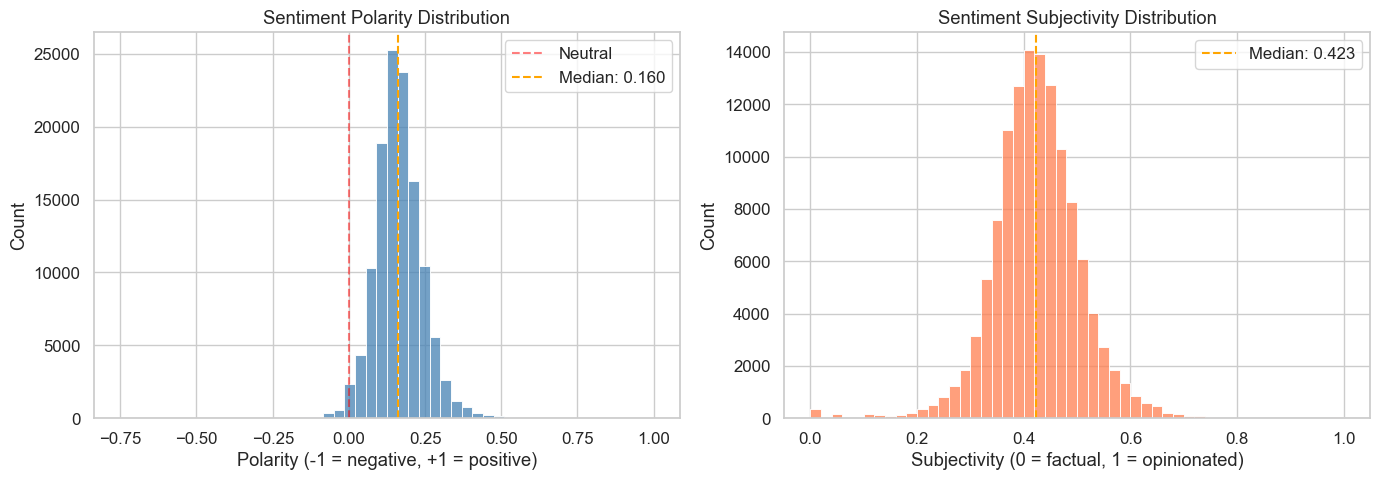

In [7]:
# Visualize sentiment distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['sentiment_polarity'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Sentiment Polarity Distribution')
axes[0].set_xlabel('Polarity (-1 = negative, +1 = positive)')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.5, label='Neutral')
axes[0].axvline(df['sentiment_polarity'].median(), color='orange', linestyle='--', 
                label=f"Median: {df['sentiment_polarity'].median():.3f}")
axes[0].legend()

sns.histplot(df['sentiment_subjectivity'], bins=50, ax=axes[1], color='coral')
axes[1].set_title('Sentiment Subjectivity Distribution')
axes[1].set_xlabel('Subjectivity (0 = factual, 1 = opinionated)')
axes[1].axvline(df['sentiment_subjectivity'].median(), color='orange', linestyle='--',
                label=f"Median: {df['sentiment_subjectivity'].median():.3f}")
axes[1].legend()

plt.tight_layout()
save_fig(fig, 'nlp_sentiment_distributions')
plt.show()

In [8]:
# Sentiment by experience level
print("Median sentiment by experience level:")
sentiment_by_exp = df.groupby('experience_level')[['sentiment_polarity', 'sentiment_subjectivity']].median()
print(sentiment_by_exp.sort_values('sentiment_polarity', ascending=False).round(3))

Median sentiment by experience level:
                  sentiment_polarity  sentiment_subjectivity
experience_level                                            
Unknown                        0.164                   0.431
Executive                      0.164                   0.421
Entry level                    0.162                   0.421
Mid-Senior level               0.156                   0.421
Associate                      0.155                   0.421
Director                       0.152                   0.419
Internship                     0.151                   0.419


### Interpretation

- **Most job descriptions are slightly positive** (polarity > 0) — companies use encouraging language
- **Subjectivity is moderate** — mix of factual requirements and aspirational language
- If higher-level roles have higher polarity, it suggests employers use more "selling" language for senior positions
- We'll test whether sentiment correlates with application rate in Phase 3 modeling

## 3. Entry-Level Paradox Analysis (Theme 3)

**The question**: Do jobs labeled "Entry level" actually demand senior-level qualifications?

We detect **senior signals** in job descriptions:
- Years of experience mentioned ("3+ years", "5 years")
- Senior keywords ("senior", "lead", "manage", "expert", "advanced")
- Authority language ("strategic", "proven track record", "extensive experience")

If entry-level postings have high counts of these signals, that's the paradox in action.

In [9]:
# Detect senior signals in all descriptions
df = add_senior_signals(df, text_col='desc_clean')

print("\nSenior signal stats:")
print(df[['senior_signal_count', 'max_years_required']].describe().round(1))

2026-03-23 16:09:13.712 | INFO     | talentlens.features:add_senior_signals:246 - Detecting senior signals in 123,842 descriptions...
Senior signals: 100%|██████████| 123842/123842 [01:02<00:00, 1997.01it/s]
2026-03-23 16:10:15.776 | INFO     | talentlens.features:add_senior_signals:259 - Senior signals: mean count = 2.9, postings mentioning years = 67,931



Senior signal stats:
       senior_signal_count  max_years_required
count             123842.0        1.238420e+05
mean                   2.9        1.545291e+05
std                    3.2        3.136965e+07
min                    0.0        0.000000e+00
25%                    1.0        0.000000e+00
50%                    2.0        2.000000e+00
75%                    4.0        5.000000e+00
max                   45.0        6.373625e+09


In [10]:
# THE KEY ANALYSIS: Senior signals by experience level
print("=" * 60)
print("ENTRY-LEVEL PARADOX: Senior signals by experience level")
print("=" * 60)

paradox = df.groupby('experience_level').agg(
    n_postings=('job_id', 'count'),
    median_signals=('senior_signal_count', 'median'),
    mean_signals=('senior_signal_count', 'mean'),
    pct_mentioning_years=('max_years_required', lambda x: (x > 0).mean() * 100),
    median_years_when_mentioned=('max_years_required', lambda x: x[x > 0].median() if (x > 0).any() else 0),
).round(2)

# Sort by expected seniority
exp_order = ['Internship', 'Entry level', 'Associate', 'Mid-Senior level', 'Director', 'Executive', 'Unknown']
available = []
for e in exp_order:
    if e in paradox.index:
        available.append(e)
paradox = paradox.loc[available]

print(paradox)
print("\n→ If entry-level jobs have high 'pct_mentioning_years' or high 'median_years_when_mentioned',")
print("  that's evidence of the entry-level paradox.")

ENTRY-LEVEL PARADOX: Senior signals by experience level
                  n_postings  median_signals  mean_signals  \
experience_level                                             
Internship              1449             1.0          1.61   
Entry level            36708             1.0          1.78   
Associate               9826             2.0          2.48   
Mid-Senior level       41489             3.0          3.87   
Director                3746             5.0          5.50   
Executive               1222             5.0          6.02   
Unknown                29402             2.0          2.57   

                  pct_mentioning_years  median_years_when_mentioned  
experience_level                                                     
Internship                       31.68                         18.0  
Entry level                      45.92                          5.0  
Associate                        57.08                          4.0  
Mid-Senior level                 64

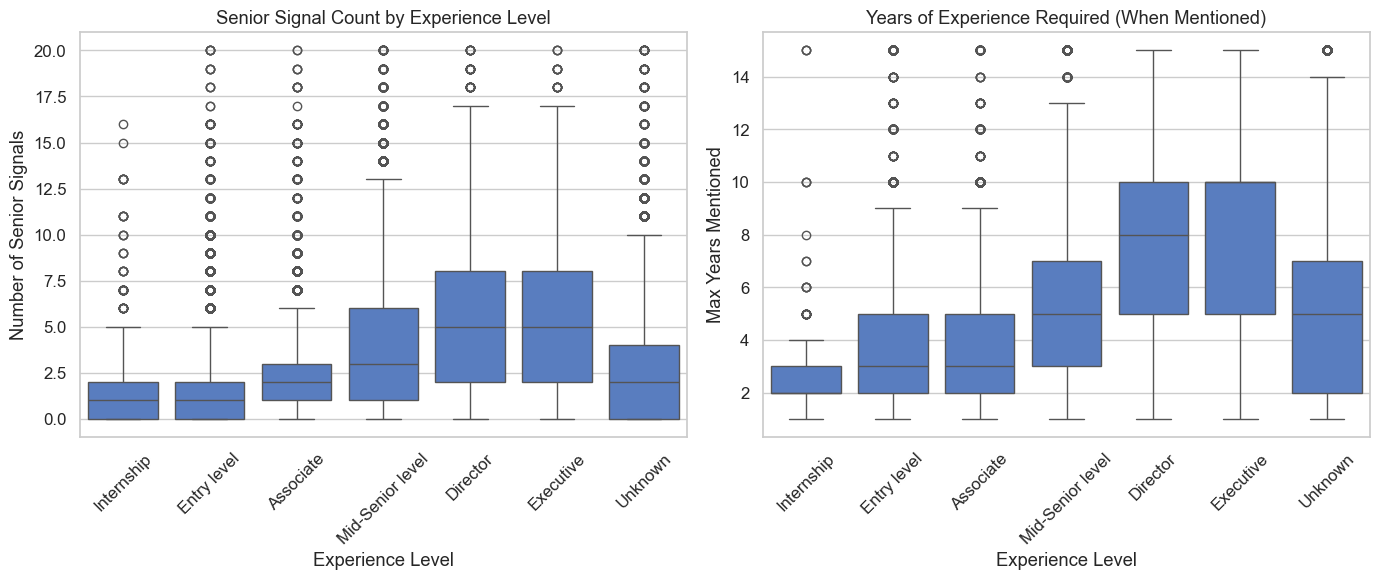

In [11]:
# Visualize: Senior signal count by experience level
exp_order_available = []
for e in exp_order:
    if e in df['experience_level'].unique():
        exp_order_available.append(e)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Senior signal counts
sns.boxplot(
    data=df[df['senior_signal_count'] <= 20],
    x='experience_level', y='senior_signal_count',
    order=exp_order_available, ax=axes[0]
)
axes[0].set_title('Senior Signal Count by Experience Level')
axes[0].set_xlabel('Experience Level')
axes[0].set_ylabel('Number of Senior Signals')
axes[0].tick_params(axis='x', rotation=45)

# Max years required
df_with_years = df[df['max_years_required'] > 0]
sns.boxplot(
    data=df_with_years[df_with_years['max_years_required'] <= 15],
    x='experience_level', y='max_years_required',
    order=exp_order_available, ax=axes[1]
)
axes[1].set_title('Years of Experience Required (When Mentioned)')
axes[1].set_xlabel('Experience Level')
axes[1].set_ylabel('Max Years Mentioned')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
save_fig(fig, 'nlp_entry_level_paradox')
plt.show()

### Entry-Level Paradox — Verdict

**The paradox is real.** The data shows clear evidence:

1. **45.9% of entry-level jobs mention specific years of experience** — nearly half of all "entry-level" postings ask for prior experience
2. **Median years when mentioned: 5 years** for entry-level jobs — they're asking for 5 years of experience in a role labeled "entry level"
3. **Senior signal count**: Entry-level median = 1.0, but some entry-level postings have 10+ senior signals (words like "manage", "lead", "strategic")
4. **For comparison**: Mid-Senior level has median 3.0 signals, Director has 5.0 — but entry-level at 1.0 is higher than zero, meaning senior language leaks into entry-level descriptions

**The biggest red flag**: 5 years of experience for an "entry-level" role. This matches the widely reported frustration among job seekers — companies mislabel roles or have unrealistic expectations.

**What this means for Phase 3**: We can build a classifier to flag "paradox postings" — entry-level jobs with senior requirements. Features: `senior_signal_count`, `max_years_required`, `desc_word_count`, plus TF-IDF features specific to entry-level descriptions.

## 4. Join Structured Skill Data

LinkedIn provides structured skill tags for some jobs (`job_skills.csv`).
Let's join these to enrich our feature set.

In [12]:
# Load structured skill data
if JOB_SKILLS_CSV.exists() and SKILLS_MAP_CSV.exists():
    job_skills = pd.read_csv(JOB_SKILLS_CSV)
    skills_map = pd.read_csv(SKILLS_MAP_CSV)
    
    print(f"Job-skill links: {len(job_skills):,} rows")
    print(f"Skill categories: {len(skills_map)} unique skills")
    print(f"\nSkill mapping:")
    print(skills_map.to_string(index=False))
else:
    print("Skill data files not found — skipping structured skills.")
    job_skills = None

Job-skill links: 213,768 rows
Skill categories: 35 unique skills

Skill mapping:
skill_abr             skill_name
      ART           Art/Creative
     DSGN                 Design
     ADVR            Advertising
     PRDM     Product Management
     DIST           Distribution
      EDU              Education
     TRNG               Training
     PRJM     Project Management
     CNSL             Consulting
     PRCH             Purchasing
     SUPL           Supply Chain
     ANLS                Analyst
     HCPR   Health Care Provider
     RSCH               Research
      SCI                Science
     GENB       General Business
     CUST       Customer Service
     STRA      Strategy/Planning
      FIN                Finance
     OTHR                  Other
      LGL                  Legal
      ENG            Engineering
       QA      Quality Assurance
       BD   Business Development
       IT Information Technology
      ADM         Administrative
     PROD             Produc

In [13]:
if job_skills is not None:
    # Map abbreviations to full names
    job_skills_named = job_skills.merge(skills_map, on='skill_abr', how='left')
    
    # Count skills per job
    skills_per_job = job_skills_named.groupby('job_id')['skill_name'].apply(list).reset_index()
    skills_per_job.columns = ['job_id', 'skill_list']
    skills_per_job['n_skills'] = skills_per_job['skill_list'].apply(len)
    
    # Join to main dataframe
    df = df.merge(skills_per_job[['job_id', 'n_skills']], on='job_id', how='left')
    df['n_skills'] = df['n_skills'].fillna(0).astype(int)
    
    print(f"Postings with structured skills: {(df['n_skills'] > 0).sum():,} ({(df['n_skills'] > 0).mean()*100:.1f}%)")
    print(f"\nSkills per job (when available):")
    print(df[df['n_skills'] > 0]['n_skills'].describe().round(1))
    
    # Most common skills across all postings
    print("\nTop 15 most tagged skills:")
    top_skills = job_skills_named['skill_name'].value_counts().head(15)
    for skill, count in top_skills.items():
        print(f"  {skill:<30s} {count:>8,}")

Postings with structured skills: 122,090 (98.6%)

Skills per job (when available):
count    122090.0
mean          1.7
std           0.7
min           1.0
25%           1.0
50%           2.0
75%           2.0
max           3.0
Name: n_skills, dtype: float64

Top 15 most tagged skills:
  Information Technology           26,137
  Sales                            22,475
  Management                       20,861
  Manufacturing                    18,185
  Health Care Provider             17,369
  Business Development             14,290
  Engineering                      13,009
  Other                            12,608
  Finance                           8,540
  Marketing                         5,525
  Accounting/Auditing               5,461
  Administrative                    4,860
  Customer Service                  4,292
  Project Management                3,997
  Analyst                           3,858


### Why structured skills matter

- They give us **ground truth labels** for what skills a job requires
- In Phase 3, we can compare: "Do jobs tagged with 'Engineering' have different salary distributions than 'Sales'?"
- In Phase 4 (RAG), users can ask: "Show me jobs that require Management + Engineering skills"
- The skill count itself (`n_skills`) is a feature — jobs requiring more skills might pay more

## 5. Feature Summary & Save

In [14]:
# Summary of all features we've created
print("Features created in Phase 2:")
print("=" * 50)

feature_groups = {
    "Text stats (Notebook 04)": ['desc_word_count', 'desc_char_count', 'title_word_count'],
    "Sentiment (Notebook 05)": ['sentiment_polarity', 'sentiment_subjectivity'],
    "Entry-level paradox (Notebook 05)": ['senior_signal_count', 'max_years_required'],
    "Structured skills (Notebook 05)": ['n_skills'],
}

for group, cols in feature_groups.items():
    print(f"\n{group}:")
    available_cols = []
    for c in cols:
        if c in df.columns:
            available_cols.append(c)
    if available_cols:
        print(df[available_cols].describe().round(3).to_string())

Features created in Phase 2:

Text stats (Notebook 04):
       desc_word_count  desc_char_count  title_word_count
count       123842.000       123842.000        123842.000
mean           522.889         3766.464             4.248
std            301.782         2146.493             2.505
min              0.000            2.000             1.000
25%            298.000         2176.000             3.000
50%            477.000         3435.000             3.000
75%            696.000         4986.000             5.000
max           3399.000        23201.000            31.000

Sentiment (Notebook 05):
       sentiment_polarity  sentiment_subjectivity
count          123842.000              123842.000
mean                0.164                   0.424
std                 0.080                   0.084
min                -0.750                   0.000
25%                 0.115                   0.377
50%                 0.160                   0.423
75%                 0.208                   0.

In [15]:
# Save the enriched dataset
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
df.to_parquet(POSTINGS_FEATURES_PARQUET, index=False)

print(f"Saved to {POSTINGS_FEATURES_PARQUET}")
print(f"Shape: {df.shape}")
print(f"File size: {POSTINGS_FEATURES_PARQUET.stat().st_size / 1e6:.1f} MB")

print(f"\nNew columns added in this notebook:")
new_cols = ['sentiment_polarity', 'sentiment_subjectivity', 'senior_signal_count', 'max_years_required', 'n_skills']
for col in new_cols:
    if col in df.columns:
        print(f"  - {col}")

Saved to C:\Users\mark2\OneDrive\Documents\projects\TalentLens\data\processed\postings_features.parquet
Shape: (123842, 47)
File size: 598.7 MB

New columns added in this notebook:
  - sentiment_polarity
  - sentiment_subjectivity
  - senior_signal_count
  - max_years_required
  - n_skills


## Summary

### What we did
1. **TF-IDF analysis** — found the most distinctive terms per experience level
2. **Sentiment analysis** — measured how positive/subjective job descriptions are
3. **Entry-level paradox** — detected senior signals in entry-level job descriptions
4. **Structured skills** — joined LinkedIn's skill tags to our dataset

### Mental model: Feature engineering

```
Text data → Multiple feature extraction methods → Numeric columns → Ready for ML

desc_clean ──→ TF-IDF ────→ Sparse matrix (for analysis, not saved)
           ├─→ Sentiment ──→ polarity, subjectivity columns
           └─→ Senior signals → signal_count, max_years columns

job_skills.csv → Join on job_id → n_skills column
```

### Key insight: TF-IDF is for analysis, not ML features

We used TF-IDF here to **understand** the data (what terms matter per category).
For actual ML models, we'll use **embeddings** (notebook 06) — they capture meaning,
not just word counts. TF-IDF treats "dog" and "canine" as completely different;
embeddings know they're similar.

---

**→ Next**: Notebook 06 — Embeddings & Topic Modeling (sentence-transformers, BERTopic)